Dataset overview:
       datum  M01AB  M01AE  N02BA  N02BE  N05B  N05C   R03  R06  Year  Month  \
0 2014-01-02    0.0   3.67    3.4  32.40   7.0   0.0   0.0  2.0  2014      1   
1 2014-01-03    8.0   4.00    4.4  50.60  16.0   0.0  20.0  4.0  2014      1   
2 2014-01-04    2.0   1.00    6.5  61.85  10.0   0.0   9.0  1.0  2014      1   
3 2014-01-05    4.0   3.00    7.0  41.10   8.0   0.0   3.0  0.0  2014      1   
4 2014-01-06    5.0   1.00    4.5  21.70  16.0   2.0   6.0  2.0  2014      1   

   Hour Weekday Name  year  month  
0   248     Thursday  2014      1  
1   276       Friday  2014      1  
2   276     Saturday  2014      1  
3   276       Sunday  2014      1  
4   276       Monday  2014      1  

Shape: 2106 rows x 15 columns
Columns: ['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name', 'year', 'month']


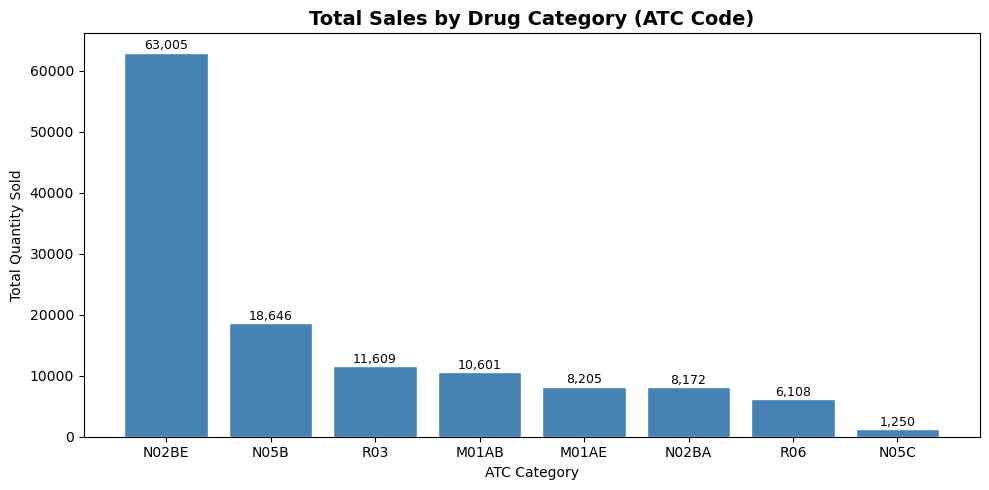


Q1 - Total sales by category:
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333


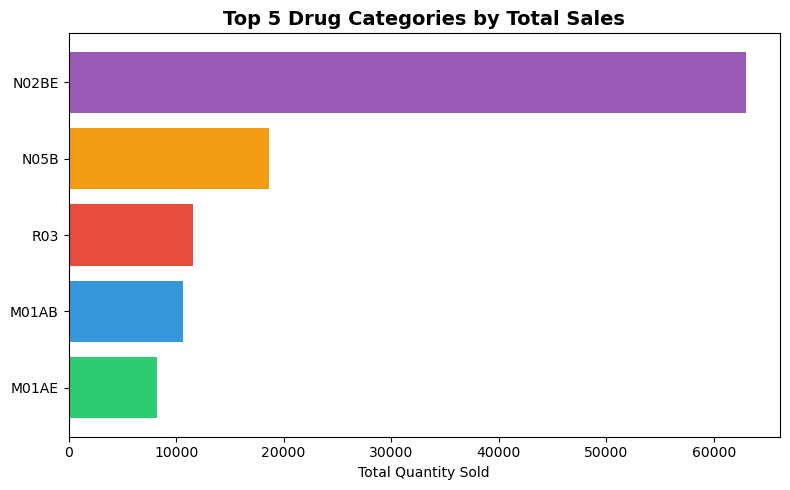


Q2 - Top 5 drugs by total sales:
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646

Q3 - Top 3 drugs in January 2015:
N02BE    1044.24
N05B      463.00
R03       177.25

Q3 - Top 3 drugs in July 2016:
N02BE    652.362000
N05B     240.000000
M01AB    194.528333

Q3 - Top 3 drugs in September 2017:
N02BE    863.75
N05B     223.00
R03      139.00


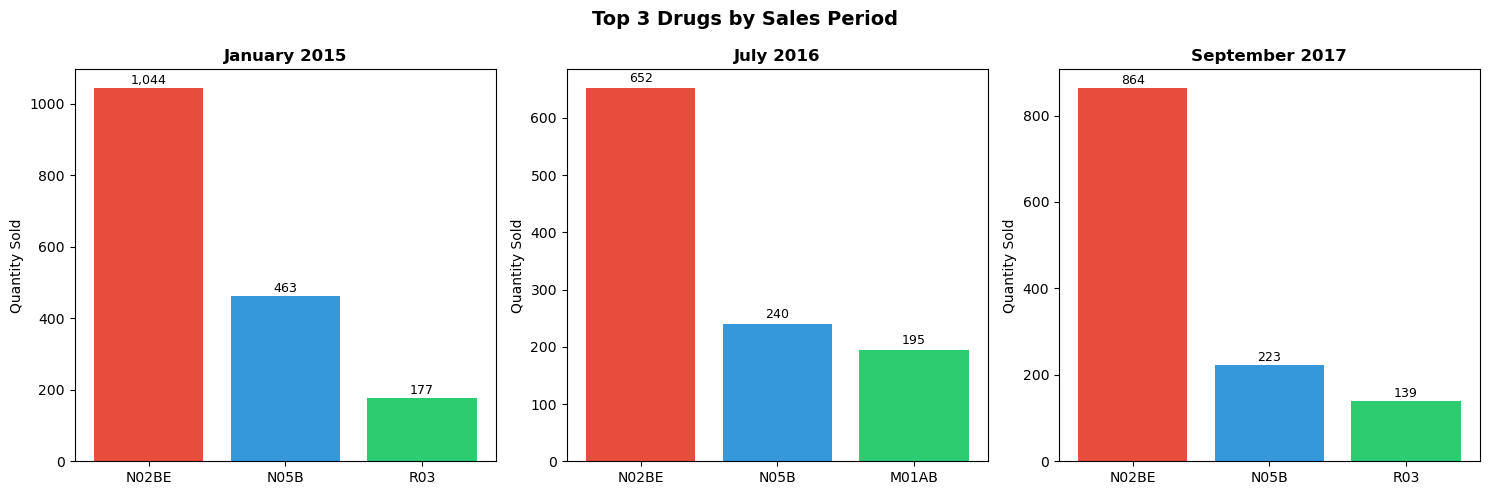

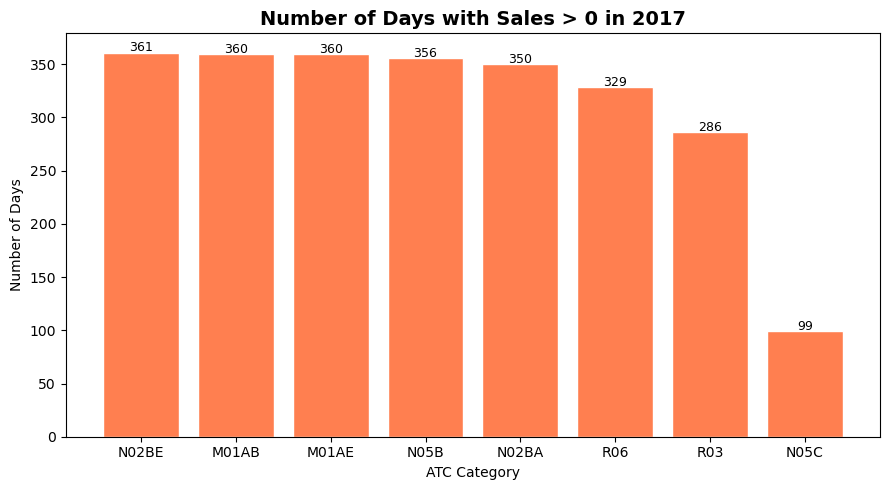


Q4 - Most frequently sold drug in 2017: N02BE (361 days)


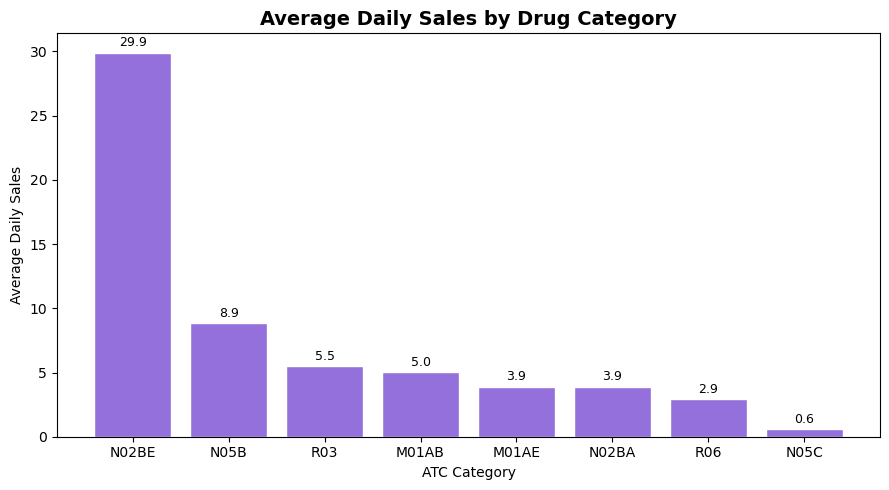


Q5 - Category with highest average daily sales: N02BE (29.92)


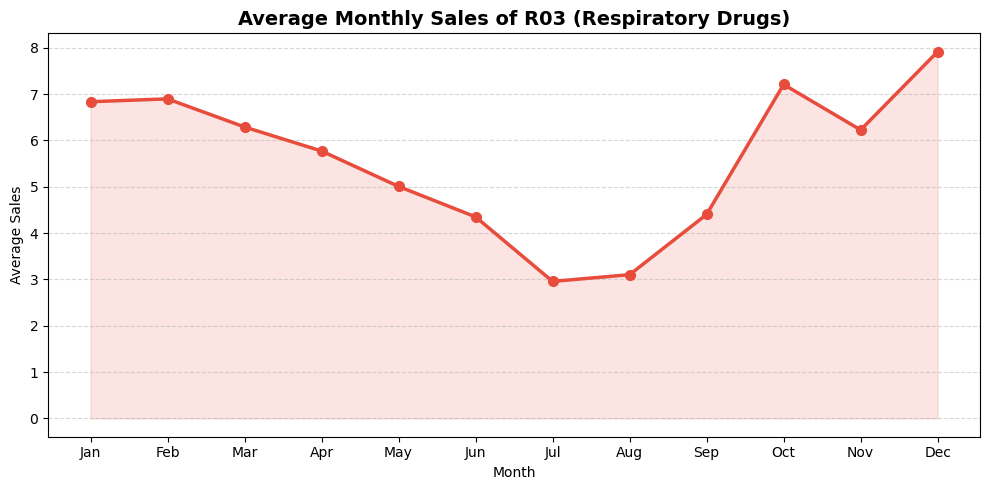


Q6 - R03 sales peak in: Dec
month
1     6.835980
2     6.896943
3     6.290323
4     5.771528
5     5.006944
6     4.350000
7     2.956989
8     3.102151
9     4.402315
10    7.208589
11    6.226667
12    7.916129

Analysis complete. All charts have been saved.


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('data/salesdaily.csv')

# Parse dates and extract year/month
df['datum'] = pd.to_datetime(df['datum'], format='mixed')
df['year']  = df['datum'].dt.year
df['month'] = df['datum'].dt.month

print("Dataset overview:")
print(df.head())
print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

# ATC drug columns
drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

# ----------------------------------------------------------
# Q1. Total sales quantities for each drug category (ATC code)
# ----------------------------------------------------------
total_by_category = df[drug_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(total_by_category.index, total_by_category.values, color='steelblue', edgecolor='white')
plt.title('Total Sales by Drug Category (ATC Code)', fontsize=14, fontweight='bold')
plt.xlabel('ATC Category')
plt.ylabel('Total Quantity Sold')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('1_total_sales_by_category.png', dpi=150)
plt.show()
print("\nQ1 - Total sales by category:")
print(total_by_category.to_string())

# ----------------------------------------------------------
# Q2. Drug brands with the highest total sales (top 5)
# ----------------------------------------------------------
top_drugs = total_by_category.head(5)

plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
plt.barh(top_drugs.index[::-1], top_drugs.values[::-1], color=colors)
plt.title('Top 5 Drug Categories by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.savefig('2_top5_drugs.png', dpi=150)
plt.show()
print("\nQ2 - Top 5 drugs by total sales:")
print(top_drugs.to_string())

# ----------------------------------------------------------
# Q3. Top 3 drugs in January 2015, July 2016, September 2017
# ----------------------------------------------------------
periods = [
    ('January 2015',   (df['year'] == 2015) & (df['month'] == 1)),
    ('July 2016',      (df['year'] == 2016) & (df['month'] == 7)),
    ('September 2017', (df['year'] == 2017) & (df['month'] == 9)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Top 3 Drugs by Sales Period', fontsize=14, fontweight='bold')

for ax, (label, mask) in zip(axes, periods):
    top3 = df[mask][drug_cols].sum().sort_values(ascending=False).head(3)
    ax.bar(top3.index, top3.values, color=['#e74c3c', '#3498db', '#2ecc71'])
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Quantity Sold')
    for i, val in enumerate(top3.values):
        ax.text(i, val + 10, f'{val:,.0f}', ha='center', fontsize=9)
    print(f"\nQ3 - Top 3 drugs in {label}:")
    print(top3.to_string())

plt.tight_layout()
plt.savefig('3_top3_by_period.png', dpi=150)
plt.show()

# ----------------------------------------------------------
# Q4. Drug sold most frequently in 2017 (most days with sales > 0)
# ----------------------------------------------------------
df_2017 = df[df['year'] == 2017]
sales_days_2017 = (df_2017[drug_cols] > 0).sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(sales_days_2017.index, sales_days_2017.values, color='coral', edgecolor='white')
plt.title('Number of Days with Sales > 0 in 2017', fontsize=14, fontweight='bold')
plt.xlabel('ATC Category')
plt.ylabel('Number of Days')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             str(bar.get_height()), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('4_most_frequent_drug_2017.png', dpi=150)
plt.show()
print(f"\nQ4 - Most frequently sold drug in 2017: {sales_days_2017.idxmax()} ({sales_days_2017.max()} days)")

# ----------------------------------------------------------
# Q5. Drug category with the highest average daily sales
# ----------------------------------------------------------
avg_daily_sales = df[drug_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(avg_daily_sales.index, avg_daily_sales.values, color='mediumpurple', edgecolor='white')
plt.title('Average Daily Sales by Drug Category', fontsize=14, fontweight='bold')
plt.xlabel('ATC Category')
plt.ylabel('Average Daily Sales')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('5_avg_daily_sales.png', dpi=150)
plt.show()
print(f"\nQ5 - Category with highest average daily sales: {avg_daily_sales.idxmax()} ({avg_daily_sales.max():.2f})")

# ----------------------------------------------------------
# Q6. Are respiratory drugs (R03) sold more during specific months?
# ----------------------------------------------------------
r03_by_month = df.groupby('month')['R03'].mean()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 5))
plt.plot(r03_by_month.index, r03_by_month.values,
         marker='o', color='#e74c3c', linewidth=2.5, markersize=7)
plt.fill_between(r03_by_month.index, r03_by_month.values, alpha=0.15, color='#e74c3c')
plt.xticks(range(1, 13), month_labels)
plt.title('Average Monthly Sales of R03 (Respiratory Drugs)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('6_r03_by_month.png', dpi=150)
plt.show()

peak_month = month_labels[r03_by_month.idxmax() - 1]
print(f"\nQ6 - R03 sales peak in: {peak_month}")
print(r03_by_month.to_string())

print("\nAnalysis complete. All charts have been saved.")